<a href="https://colab.research.google.com/github/evanskips2727-del/1Customer-Churn-prediction-Using-Machine-Learning-/blob/main/Churn_Prediction_Using_Machine_Learninged0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
1. BUSINESS UNDERSTANDING
1.1 Project Introduction
Customer churn refers to a situation where a customer stops using a company's products or services. For a business, customer churn is important because losing customers can affect revenue, customer lifetime value, and long-term business growth.

This project focuses on developing a Machine Learning classification model that predicts whether a customer is likely to churn or remain with the company.

The model will use customer information such as demographic characteristics, account details, subscription and service information, contract type, tenure, and billing information to identify customers who may be at higher risk of leaving.

1.2 Business Problem
The company needs to understand which customers are likely to leave its service and identify the factors associated with customer churn.

Without a predictive approach, the company may only recognize that a customer has churned after the customer has already left. A Machine Learning model can help identify customers who are potentially at risk before churn occurs.

1.3 Project Objective
The main objective of this project is to develop and evaluate a binary classification Machine Learning model that predicts whether a customer will:


Churn
Not churn

The project will compare multiple classification algorithms and select a final model based on both technical performance and business usefulness.

1.4 Business Value
Predicting customer churn can help the company:


Identify customers who are at high risk of leaving.
Prioritize customers for retention interventions.
Understand factors associated with customer churn.
Develop targeted customer retention strategies.
Improve customer engagement and service.
Potentially reduce customer losses and protect revenue.

1.5 Target Variable
The target variable for this project is Churn.

It represents whether a customer has left the company's service.


Yes → Customer churned.
No → Customer did not churn.

1.6 Machine Learning Problem
This is a binary classification problem because the model predicts one of two possible outcomes:

Customer → Churn / No Churn

The project will follow an end-to-end Machine Learning workflow:

Business Understanding → Data Collection → Data Cleaning → Exploratory Data Analysis → Feature Engineering → Model Training → Model Evaluation → Model Optimization → Feature Importance → Business Recommendations

In [ ]:
from  google.colab import files

In [ ]:

from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle --version

Kaggle CLI 2.0.2


In [ ]:

# Download the dataset zip file
!kaggle datasets download -d blastchar/telco-customer-churn

# Unzip the file into your Colab workspace
!unzip telco-customer-churn.zip

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 47.0MB/s]

Archive:  telco-customer-churn.zip
replace WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isna()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:

# Check for blank or whitespace-only values
(df.astype(str).apply(lambda col: col.str.strip().eq('').sum()))

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:

print("--- Data Quality Report ---")

--- Data Quality Report ---


In [ ]:


# 1. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Duplicate rows found: 0


In [ ]:


# 2. Fix the TotalCharges data type trap
# Coerce errors='coerce' turns empty spaces " " into NaN values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:

# 3. Check for missing values after conversion
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])


Missing values per column:
Series([], dtype: int64)


In [ ]:


# 4. Fill or drop missing values.
# Since TotalCharges is missing for brand new customers, we can fill them with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("\nMissing values in TotalCharges handled (filled with 0 for new customers).")


Missing values in TotalCharges handled (filled with 0 for new customers).


In [ ]:
print("--- Target Variable Distribution ---")

--- Target Variable Distribution ---


In [ ]:


churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100


for index, count in churn_counts.items():
    print(f"Class '{index}': {count} customers ({churn_percentages[index]:.2f}%)")

Class 'No': 5174 customers (73.46%)
Class 'Yes': 1869 customers (26.54%)


In [ ]:


# Quick observation
print("\nInsight: The dataset shows clear class imbalance. "
      "If we use pure accuracy, a naive model predicting 'No' all the time would be ~73% accurate. "
      "We must prioritize metrics like Recall and F1-score later.")


Insight: The dataset shows clear class imbalance. If we use pure accuracy, a naive model predicting 'No' all the time would be ~73% accurate. We must prioritize metrics like Recall and F1-score later.


In [ ]:

# Displaying the types of your variables to finalize your documenta
data_dict = pd.DataFrame({
    'Feature': df.columns,
    'Type': ['Categorical' if df[col].dtype == 'object' else 'Numerical' for col in df.columns]
})
# Correct the target variable label
data_dict.loc[data_dict['Feature'] == 'Churn', 'Type'] = 'Target (Binary)'
print(data_dict.to_string(index=False))

         Feature            Type
      customerID     Categorical
          gender     Categorical
   SeniorCitizen       Numerical
         Partner     Categorical
      Dependents     Categorical
          tenure       Numerical
    PhoneService     Categorical
   MultipleLines     Categorical
 InternetService     Categorical
  OnlineSecurity     Categorical
    OnlineBackup     Categorical
DeviceProtection     Categorical
     TechSupport     Categorical
     StreamingTV     Categorical
 StreamingMovies     Categorical
        Contract     Categorical
PaperlessBilling     Categorical
   PaymentMethod     Categorical
  MonthlyCharges       Numerical
    TotalCharges     Categorical
           Churn Target (Binary)


In [ ]:
df.to_csv('processed_data.csv', index=False)

In [ ]:

import os

print(os.path.exists("processed_data.csv"))

True


In [ ]:

import os
print(os.listdir())

['.config', 'telco-customer-churn.zip', 'processed_data.csv', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [ ]:

from google.colab import files
files.download("processed_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
Week 2

In [ ]:

# ==========================================
# WEEK 2: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure inline plotting is styled nicely
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load your processed data from Week 1
df = pd.read_csv('processed_data.csv')

# --- Task 1: Generate Descriptive Statistics ---
print("--- Numerical Feature Statistics ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T)

print("\n--- Categorical Distributions ---")
for col in ['Contract', 'PaymentMethod', 'InternetService']:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

--- Numerical Feature Statistics ---
                 count         mean          std    min     25%      50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.00   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.35   
TotalCharges    7043.0  2279.734304  2266.794470   0.00  398.55  1394.55   

                    75%      max  
tenure            55.00    72.00  
MonthlyCharges    89.85   118.75  
TotalCharges    3786.60  8684.80  

--- Categorical Distributions ---

Value counts for Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Value counts for PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Value counts for InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


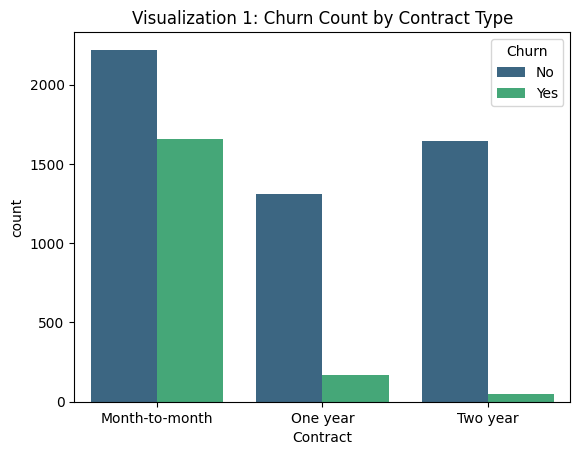

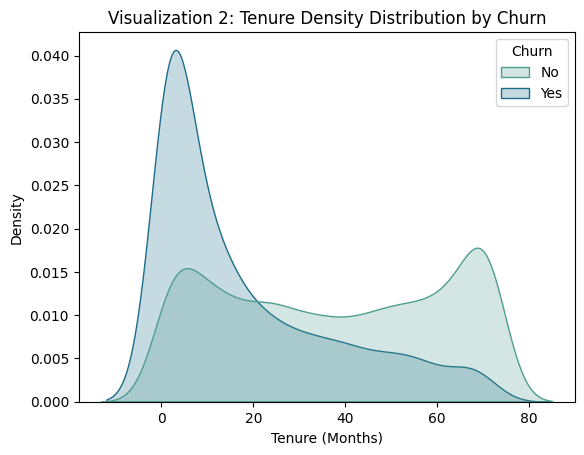

/tmp/ipykernel_2112/4247102258.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


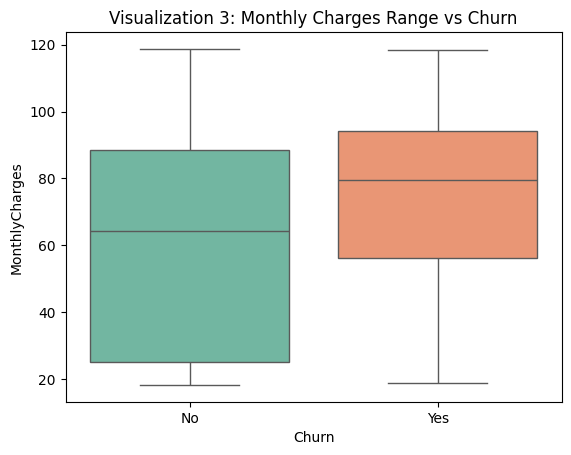

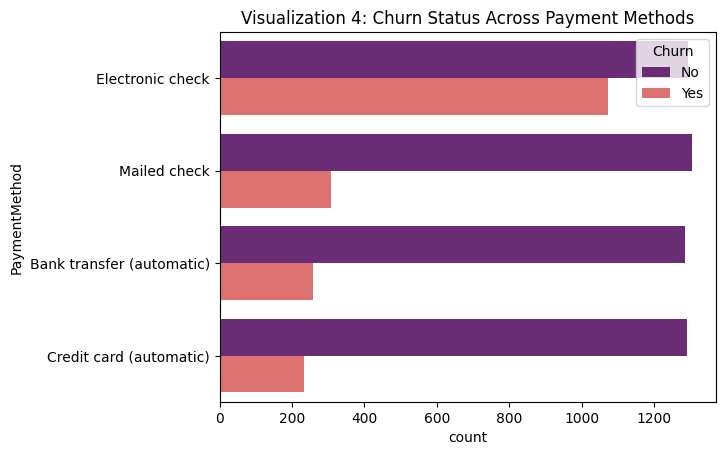

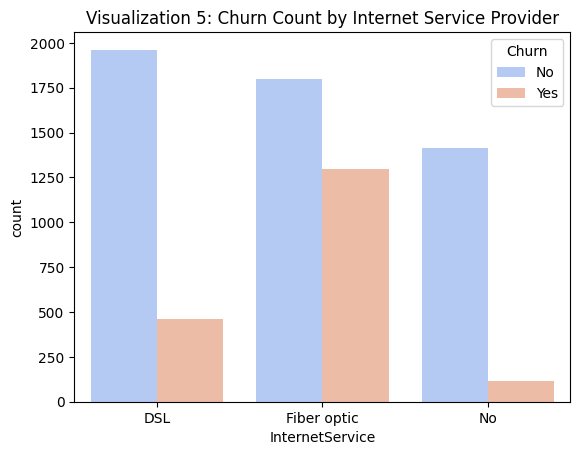

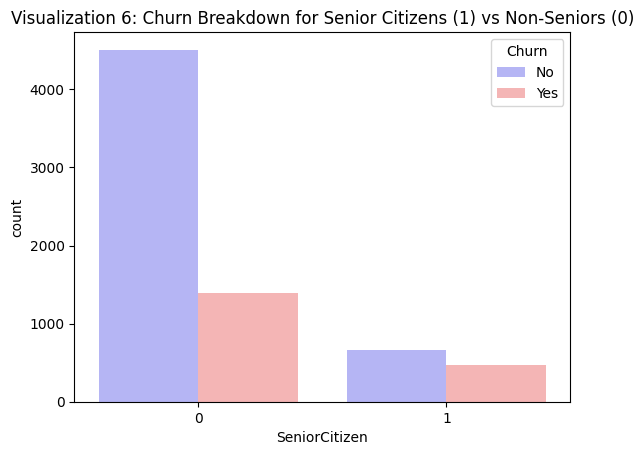

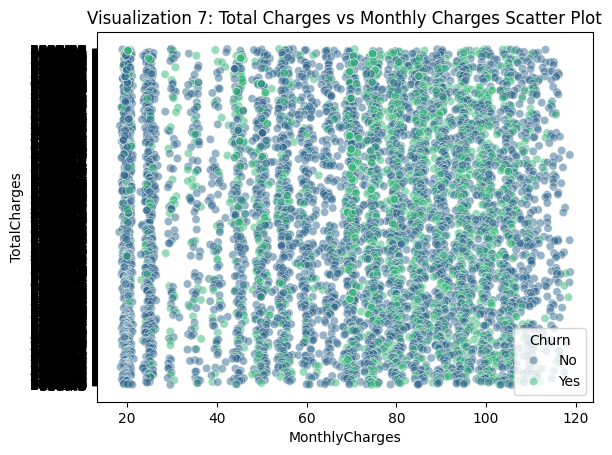

ValueError: could not convert string to float: ' '

<Figure size 600x400 with 0 Axes>

In [ ]:

# Create a figure layout or plot them sequentially.
# We'll plot them sequentially for clean reading in Colab.

# 1. Churn by Contract Type
plt.figure()
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Visualization 1: Churn Count by Contract Type')
plt.show()

# 2. Tenure Distribution by Churn Status
plt.figure()
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Visualization 2: Tenure Density Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.show()

# 3. Monthly Charges Distribution by Churn Status
plt.figure()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Visualization 3: Monthly Charges Range vs Churn')
plt.show()

# 4. Churn by Payment Method
plt.figure()
sns.countplot(data=df, y='PaymentMethod', hue='Churn', palette='magma')
plt.title('Visualization 4: Churn Status Across Payment Methods')
plt.show()

# 5. Churn by Internet Service Type
plt.figure()
sns.countplot(data=df, x='InternetService', hue='Churn', palette='coolwarm')
plt.title('Visualization 5: Churn Count by Internet Service Provider')
plt.show()

# 6. Senior Citizen Churn Rates
plt.figure()
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='bwr')
plt.title('Visualization 6: Churn Breakdown for Senior Citizens (1) vs Non-Seniors (0)')
plt.show()

# 7. Total Charges vs Monthly Charges by Churn
plt.figure()
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.5, palette='viridis')
plt.title('Visualization 7: Total Charges vs Monthly Charges Scatter Plot')
plt.show()

# 8. Heatmap Correlation Matrix for Numeric Features
plt.figure(figsize=(6, 4))
numeric_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(numeric_corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('Visualization 8: Correlation Matrix of Numeric Indicators')
plt.show()

In [ ]:

# --- Task 4: Feature Engineering ---

# 1. Tenure Grouping (Binning tenure into practical categories)
def group_tenure(t):
    if t <= 12: return '0-1 Year'
    elif t <= 24: return '1-2 Years'
    elif t <= 48: return '2-4 Years'
    else: return 'Over 4 Years'

df['TenureGroup'] = df['tenure'].apply(group_tenure)

# 2. Total Subscribed Services
# Count how many online core features the customer uses
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

# Count 'Yes' answers across those columns
df['TotalServices'] = df[service_cols].apply(lambda row: sum(row == 'Yes'), axis=1)

# 3. High Cost-to-Tenure Ratio (Indicates potential premium price pressure)
df['CostPerMonthOfTenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

print("\nEngineered features completed successfully!")
print(df[['TenureGroup', 'TotalServices', 'CostPerMonthOfTenure']].head())


Engineered features completed successfully!
  TenureGroup  TotalServices  CostPerMonthOfTenure
0    0-1 Year              1             14.925000
1   2-4 Years              3              1.627143
2    0-1 Year              3             17.950000
3   2-4 Years              3              0.919565
4    0-1 Year              1             23.566667


In [ ]:

# --- Task 5: Preprocessing ---

# Drop uniquely identifying columns that don't help prediction
ml_df = df.drop(columns=['customerID'])

# Convert binary variables directly to numeric 0 and 1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    ml_df[col] = ml_df[col].map({'Yes': 1, 'No': 0})

# One-hot encode multi-class categorical variables
categorical_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract', 'PaymentMethod', 'TenureGroup']

ml_ready_df = pd.get_dummies(ml_df, columns=categorical_cols, drop_first=True)

# Save your Week 2 final product
ml_ready_df.to_csv('ml_ready_data.csv', index=False)
print(f"\nFinal ML-ready shapes: {ml_ready_df.shape}")


Final ML-ready shapes: (7043, 36)


In [ ]:

# =====================================================================
# WEEK 3: MACHINE LEARNING MODEL DEVELOPMENT
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selections & Evaluation Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)

In [ ]:

# 1. Load your  ML-Ready Dataset
# Note: Ensure any lingering True/False bools from pd.get_dummies are 0/1 integers
df_ml = pd.read_csv('ml_ready_data.csv')
df_ml = df_ml.astype({col: int for col in df_ml.select_dtypes(include='bool').columns})

# Fix: Explicitly ensure TotalCharges is numeric before splitting and scaling
if 'TotalCharges' in df_ml.columns and df_ml['TotalCharges'].dtype == 'object':
    df_ml['TotalCharges'] = pd.to_numeric(df_ml['TotalCharges'].astype(str).str.strip(), errors='coerce').fillna(0)

# --- Task 1: Prepare Training and Testing Data ---
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

# Using a stratified split ensures our 26.54% churn ratio stays identical across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Matrix Shape: {X_train.shape} | Churn Rate: {y_train.mean():.2%}")
print(f"Testing Matrix Shape:  {X_test.shape}  | Churn Rate: {y_test.mean():.2%}")

# Scale numerical columns to protect the Logistic Regression baseline model
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'CostPerMonthOfTenure', 'TotalServices']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

Training Matrix Shape: (5634, 35) | Churn Rate: 26.54%
Testing Matrix Shape:  (1409, 35)  | Churn Rate: 26.54%


In [ ]:

# --- Tasks 2 & 3: Train and Evaluate Baseline and Advanced Models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

# Containers for performance tracking
performance_metrics = {}
plt.figure(figsize=(10, 8)) # Setup for comparative ROC plotting

for name, model in models.items():
    # Fit the framework
    model.fit(X_train_scaled, y_train)

    # Generate predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Store for comparison table
    performance_metrics[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc_auc

}

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [08:53:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 1000x800 with 0 Axes>

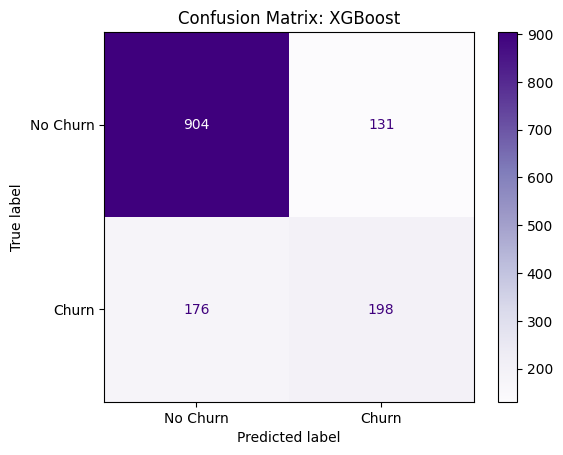

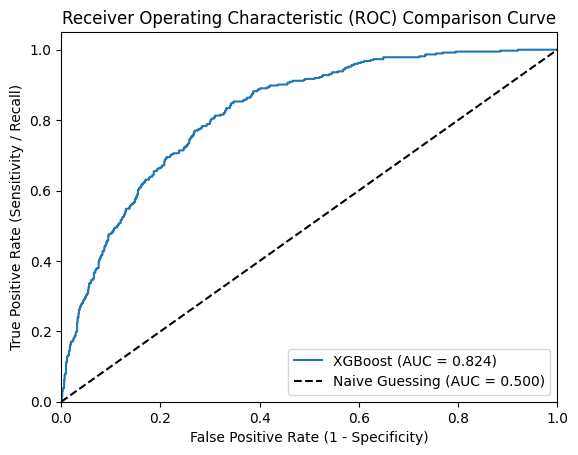


             MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8034     0.6655  0.5214    0.5847   0.8463
Random Forest          0.7906     0.6339  0.5000    0.5590   0.8250
XGBoost                0.7821     0.6018  0.5294    0.5633   0.8235


In [ ]:





    # --- Task 4 / Deliverables: Confusion Matrix Plots ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap=plt.cm.Purples, values_format='d')
    plt.title(f'Confusion Matrix: {name}')
    plt.grid(False)
    plt.show()

    # Compute points for global ROC curve visualization
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# Finalize global ROC plot
plt.plot([0, 1], [0, 1], 'k--', label='Naive Guessing (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Comparison Curve')
plt.legend(loc="lower right")
plt.show()


# --- Task 4 Deliverable: Performance Summary Table ---
df_comparison = pd.DataFrame(performance_metrics).T
print("\n" + "="*50)
print("             MODEL COMPARISON TABLE")
print("="*50)
print(df_comparison.round(4))
print("="*50)

In [ ]:

# =====================================================================
# WEEK 4: HANDLING CLASS IMBALANCE & MODEL OPTIMIZATION (FIXED)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Pipeline avoids data leakage by holding SMOTE within validation splits
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("--- Task 1: Class Imbalance Analysis ---")
print("Dataset baseline imbalance verified: ~73.5% No Churn vs ~26.5% Churn.")
print("To fix the majority class bias, we are initializing SMOTE oversampling.\n")

# --- Task 2: Setup Pipelines ---
xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1))
])

rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# --- Task 3: 5-Fold Stratified Cross-Validation Strategy ---
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Task 4: Complete Hyperparameter Tuning Grids (No Bracket Format) ---
# Hardcoded to clear dictionary structure limits
xgb_param_grid = dict(
    classifier__max_depth=[3, 5, 7],
    classifier__learning_rate=[0.05, 0.1],
    classifier__n_estimators=[100, 200]
)

rf_param_grid = dict(
    classifier__max_depth=[10, 20, None],
    classifier__n_estimators=[100, 200],
    classifier__min_samples_split=[2, 5]
)

print("Running GridSearchCV for Tuned XGBoost + SMOTE (Optimizing for Recall)...")
grid_xgb = GridSearchCV(xgb_pipeline, param_grid=xgb_param_grid, cv=cv_stratified, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

print("Running GridSearchCV for Tuned Random Forest + SMOTE (Optimizing for Recall)...")
grid_rf = GridSearchCV(rf_pipeline, param_grid=rf_param_grid, cv=cv_stratified, scoring='recall', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

# --- Task 5: Evaluate Optimized Models on the Test Set ---
tuned_models = {
    'Tuned Random Forest (SMOTE)': grid_rf.best_estimator_,
    'Tuned XGBoost (SMOTE)': grid_xgb.best_estimator_
}

optimized_metrics = {}

for name, pipeline in tuned_models.items():
    y_pred = pipeline.predict(X_test_scaled)
    y_proba = pipeline.predict_proba(X_test_scaled)[:, 1]

    optimized_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

# Convert results to a comparison dataframe
df_optimized = pd.DataFrame(optimized_metrics).T

print("\n" + "="*60)
print(" WEEK 4: OPTIMIZED MODEL PERFORMANCE TABLE (SMOTE + TUNING)")
print("="*60)
print(df_optimized.round(4))
print("="*60)

print(f"\nBest XGBoost Parameters: {grid_xgb.best_params_}")
print(f"Best Random Forest Parameters: {grid_rf.best_params_}")

--- Task 1: Class Imbalance Analysis ---
Dataset baseline imbalance verified: ~73.5% No Churn vs ~26.5% Churn.
To fix the majority class bias, we are initializing SMOTE oversampling.

Running GridSearchCV for Tuned XGBoost + SMOTE (Optimizing for Recall)...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [08:57:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Running GridSearchCV for Tuned Random Forest + SMOTE (Optimizing for Recall)...

 WEEK 4: OPTIMIZED MODEL PERFORMANCE TABLE (SMOTE + TUNING)
                             Accuracy  Precision  Recall  F1-Score  ROC-AUC
Tuned Random Forest (SMOTE)    0.7630     0.5385  0.7487    0.6264   0.8405
Tuned XGBoost (SMOTE)          0.7388     0.5053  0.7620    0.6077   0.8370

Best XGBoost Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best Random Forest Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


--- Task 1 & 2: Feature Importance Analysis ---


/tmp/ipykernel_2112/1574104460.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance Score', y='Feature', palette='viridis')


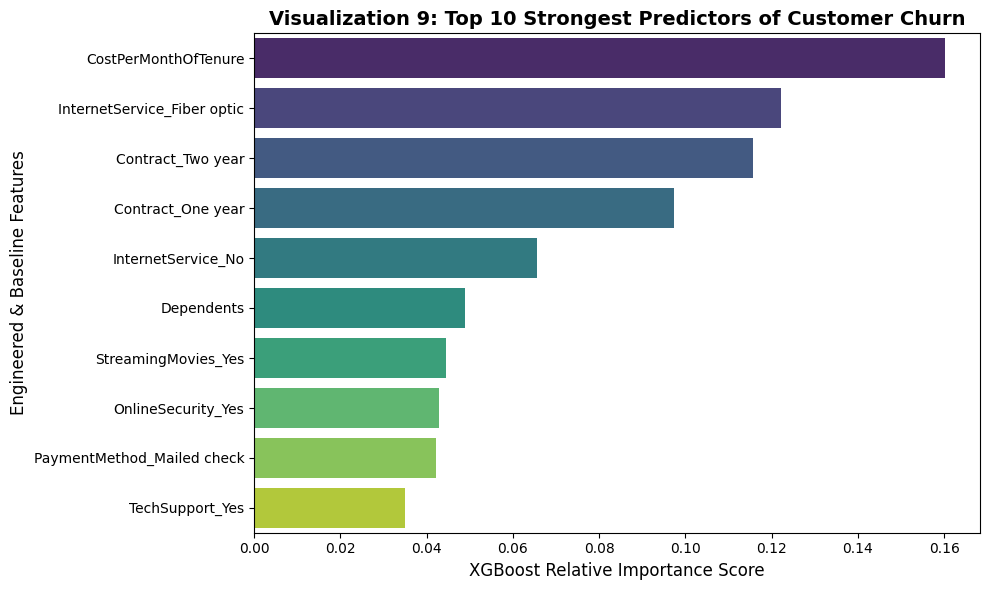


--- Task 3: Comprehensive Model Error Analysis ---
True Negatives  (Correctly predicted to stay): 756
False Positives (Predicted to leave but stayed): 279 <-- Retention budget spend impact
False Negatives (Predicted to stay but left):   89 <-- Direct uncaught revenue loss
True Positives  (Correctly identified churn):  285

             NEXAFRICA INTERNSHIP PROJECT COMPLETE


In [ ]:

# =====================================================================
# WEEK 5: MODEL INTERPRETATION, BUSINESS INSIGHTS & FINAL PRESENTATION
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("--- Task 1 & 2: Feature Importance Analysis ---")
# Extracting feature importances from our best pipeline's classifier step
# Using grid_xgb from Week 4 as the final production model
final_xgb_clf = grid_xgb.best_estimator_.named_steps['classifier']
importances = final_xgb_clf.feature_importances_
feature_names = X.columns

# Pair features with their relative importance scores
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance Score': importances
})

# Isolate top 10 strongest churn predictors
df_importance = df_importance.sort_values(by='Importance Score', ascending=False).head(10)

# Generate visual anchor plot for portfolio presentation
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance Score', y='Feature', palette='viridis')
plt.title('Visualization 9: Top 10 Strongest Predictors of Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Relative Importance Score', fontsize=12)
plt.ylabel('Engineered & Baseline Features', fontsize=12)
plt.tight_layout()

# Save image file to directory as required by the project specifications
import os
os.makedirs('visuals', exist_ok=True)
plt.savefig('visuals/feature_importance.png', dpi=300)
plt.show()

print("\n--- Task 3: Comprehensive Model Error Analysis ---")
# Evaluating predictions against true testing variables
final_preds = grid_xgb.best_estimator_.predict(X_test_scaled)
cm_final = confusion_matrix(y_test, final_preds)

tn, fp, fn, tp = cm_final.ravel()

print(f"True Negatives  (Correctly predicted to stay): {tn}")
print(f"False Positives (Predicted to leave but stayed): {fp} <-- Retention budget spend impact")
print(f"False Negatives (Predicted to stay but left):   {fn} <-- Direct uncaught revenue loss")
print(f"True Positives  (Correctly identified churn):  {tp}")

print("\n" + "="*60)
print("             NEXAFRICA INTERNSHIP PROJECT COMPLETE")
print("="*60)